CUDA tersedia: True
Nama GPU: Tesla T4
Peranti aktif: cuda
Laluan dataset: /content/Dataset/data_dogcat
Kelas train: ['cats', 'dogs']
Kelas test : ['cats', 'dogs']
Nama kelas      : ['cats', 'dogs']
Pemetaan kelas  : {'cats': 0, 'dogs': 1}
Imej latihan    : 120
Imej pengujian  : 99


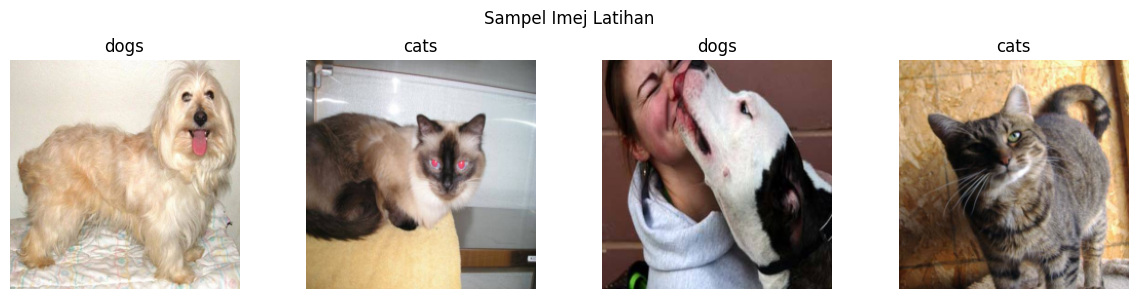

KVTRONCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Model berada pada peranti: cuda:0
Epoch 1/3 - Loss: 0.9316 - Accuracy: 45.83%
Epoch 2/3 - Loss: 0.6926 - Accuracy: 50.83%
Epoch 3/3 - Loss: 0.6681 - Accuracy: 65.83%
Ketepatan uji

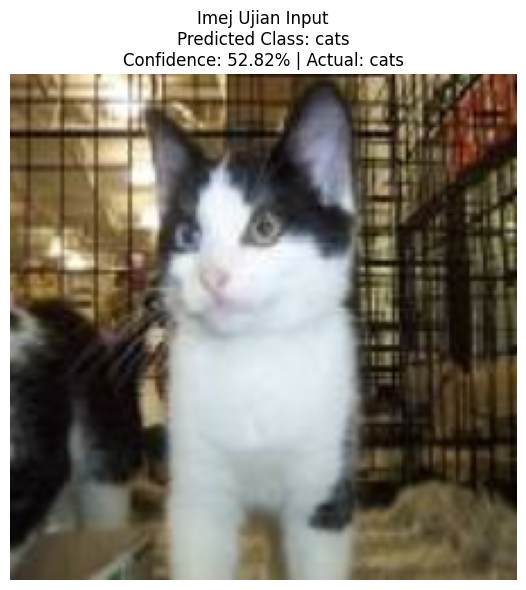

Indeks kelas ramalan: 0
Nama kelas ramalan  : cats
Nilai keyakinan      : 52.82%
Model berjaya disimpan sebagai: /content/kvtron_catdog_cnn_model.pth


In [6]:
# =============================================================================
# DKA3223 AMALI 1 - KV-TRON CNN IMAGE CLASSIFICATION
# Nama: Fahd Esmael
# Angka Giliran: SILA_ISI_ANGKA_GILIRAN
# =============================================================================
# Hak cipta dataset:
# Dataset imej kucing dan anjing ini digunakan untuk tujuan pendidikan DKA3223
# sahaja. Hak cipta imej kekal milik pemilik/sumber asal masing-masing.
#
# Etika pembangunan AI:
# Model ini dibangunkan untuk pembelajaran dan simulasi kawalan kualiti visual.
# Data peribadi tidak boleh dimasukkan tanpa kebenaran. Keputusan model mesti
# disemak manusia kerana ramalan AI boleh tersilap dan tidak wajar digunakan
# untuk membuat keputusan berisiko tinggi secara automatik.
# =============================================================================

import os
import random
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# LANGKAH 1: Kebolehulangan dan semakan peranti GPU/CUDA
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("CUDA tersedia:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nama GPU:", torch.cuda.get_device_name(0))
else:
    print("Nama GPU: GPU tidak tersedia - CPU akan digunakan")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Peranti aktif:", device)


# LANGKAH 2: Sediakan dataset
# Di Google Colab, muat naik Dataset.zip ke /content melalui panel Files.
dataset_zip = "/content/Dataset.zip"

if not os.path.exists(dataset_zip):
    try:
        from google.colab import files

        print("Pilih dan muat naik fail Dataset.zip")
        uploaded = files.upload()
        zip_names = [name for name in uploaded if name.lower().endswith(".zip")]
        if not zip_names:
            raise FileNotFoundError("Tiada fail ZIP dimuat naik.")
        dataset_zip = os.path.join("/content", zip_names[0])
    except ModuleNotFoundError as exc:
        raise FileNotFoundError(
            "Dataset.zip tidak ditemui. Jalankan kod ini dalam Google Colab "
            "atau ubah nilai dataset_zip kepada laluan sebenar."
        ) from exc

extract_dir = "/content"
with zipfile.ZipFile(dataset_zip, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

dataset_candidates = [
    "/content/Dataset/data_dogcat",
    "/content/data_dogcat",
]
dataset_path = next(
    (path for path in dataset_candidates if os.path.isdir(path)),
    None,
)
if dataset_path is None:
    raise FileNotFoundError(
        "Folder data_dogcat tidak ditemui selepas Dataset.zip diekstrak."
    )

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")
if not os.path.isdir(train_dir) or not os.path.isdir(test_dir):
    raise FileNotFoundError("Folder train atau test tidak ditemui dalam dataset.")

print("Laluan dataset:", dataset_path)
print("Kelas train:", sorted(os.listdir(train_dir)))
print("Kelas test :", sorted(os.listdir(test_dir)))


# LANGKAH 3: Pra-pemprosesan imej mengikut spesifikasi soalan
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ]
)

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

if train_dataset.class_to_idx != test_dataset.class_to_idx:
    raise ValueError("Pemetaan kelas train dan test tidak sepadan.")

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    generator=loader_generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

class_names = train_dataset.classes
print("Nama kelas      :", class_names)
print("Pemetaan kelas  :", train_dataset.class_to_idx)
print("Imej latihan    :", len(train_dataset))
print("Imej pengujian  :", len(test_dataset))


# Visualisasi sampel - nyahnormalisasi untuk paparan warna yang betul
def denormalize(image_tensor):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return torch.clamp(image_tensor.cpu() * std + mean, 0, 1)


sample_images, sample_labels = next(iter(train_loader))
plt.figure(figsize=(12, 3))
for index in range(min(4, len(sample_images))):
    plt.subplot(1, 4, index + 1)
    image_to_show = denormalize(sample_images[index]).permute(1, 2, 0)
    plt.imshow(image_to_show)
    plt.title(class_names[sample_labels[index].item()])
    plt.axis("off")
plt.suptitle("Sampel Imej Latihan")
plt.tight_layout()
plt.show()


# LANGKAH 4: Bina model CNN asas
INPUT_CHANNELS = 3
OUTPUT_CLASSES = len(class_names)


class KVTRONCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(INPUT_CHANNELS, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # Saiz 224x224 menjadi 28x28 selepas tiga lapisan MaxPool2d(2).
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, OUTPUT_CLASSES),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = KVTRONCNN().to(device)
print(model)
print("Model berada pada peranti:", next(model.parameters()).device)


# LANGKAH 5: Hyperparameter dan latihan model
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 3

training_history = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    training_history.append((epoch_loss, epoch_accuracy))
    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"Loss: {epoch_loss:.4f} - Accuracy: {epoch_accuracy * 100:.2f}%"
    )


# LANGKAH 6: Penilaian model pada set ujian
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total if total else 0.0
print(f"Ketepatan ujian: {test_accuracy * 100:.2f}%")


# LANGKAH 7: Inferens imej tunggal dan confidence score
input_image, actual_label = test_dataset[0]

input_tensor = input_image.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted_index = torch.max(probabilities, dim=1)

predicted_index = predicted_index.item()
predicted_class = class_names[predicted_index]
actual_class = class_names[actual_label]
confidence_percent = confidence.item() * 100

plt.figure(figsize=(6, 6))
plt.imshow(denormalize(input_image).permute(1, 2, 0))
plt.title(
    f"Imej Ujian Input\n"
    f"Predicted Class: {predicted_class}\n"
    f"Confidence: {confidence_percent:.2f}% | Actual: {actual_class}"
)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Indeks kelas ramalan:", predicted_index)
print("Nama kelas ramalan  :", predicted_class)
print(f"Nilai keyakinan      : {confidence_percent:.2f}%")


# LANGKAH 8: Simpan model
save_path = "/content/kvtron_catdog_cnn_model.pth"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_to_idx": train_dataset.class_to_idx,
        "input_size": (224, 224),
        "mean": MEAN,
        "std": STD,
    },
    save_path,
)
print("Model berjaya disimpan sebagai:", save_path)
